Part 1: Data Import & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
# Loading the dataset
df = pd.read_csv("C:\\Users\\sudda\\Downloads\\archive (11)\\heart_disease_uci.csv")
# Displaying first 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
#printing the shape of the dataset
print("Dataset shape:", df.shape)
#Checking missing values
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (920, 16)

Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [5]:
#handling missing values
df = df.dropna()

In [7]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [8]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

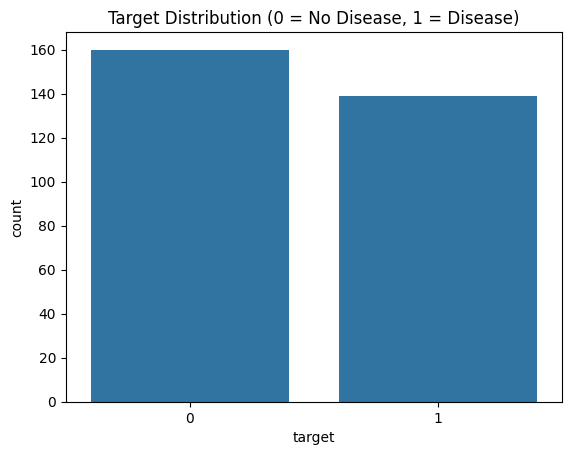

In [9]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution (0 = No Disease, 1 = Disease)")
plt.show()

The dataset appears balanced if both bars are similar in height. If one class dominates, it is imbalanced.

Part 2: Exploratory Data Analysis (EDA)

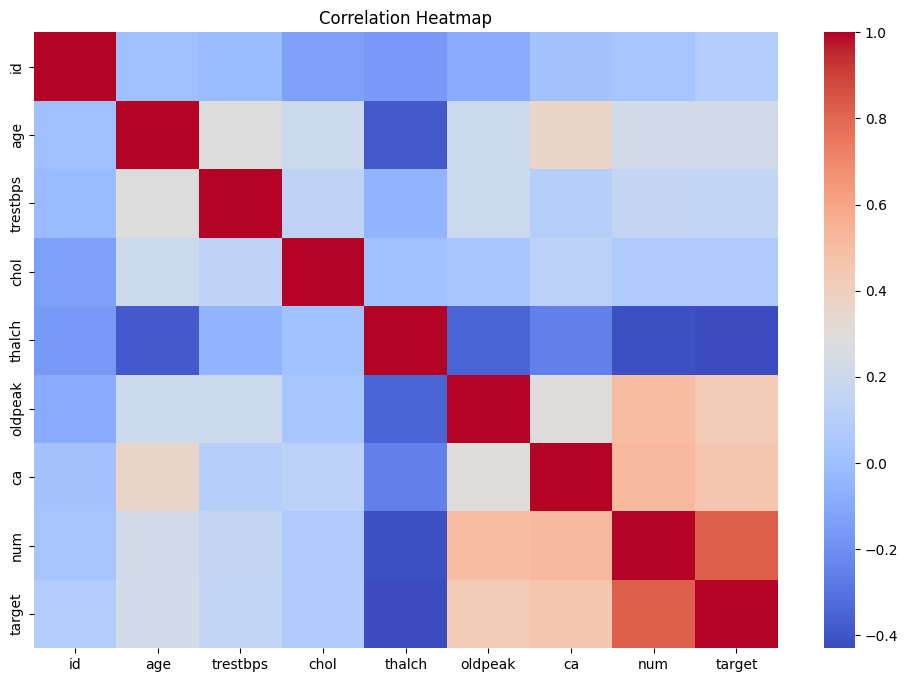

target      1.000000
num         0.826696
ca          0.455398
oldpeak     0.424947
age         0.223498
trestbps    0.153849
id          0.082766
chol        0.067350
thalch     -0.430108
Name: target, dtype: float64


In [11]:
#Selecting only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#Correlation with target
print(numeric_df.corr()['target'].sort_values(ascending=False))

Features such as cp,thalach,and oldpeak often showing strong correlation with heart disease.

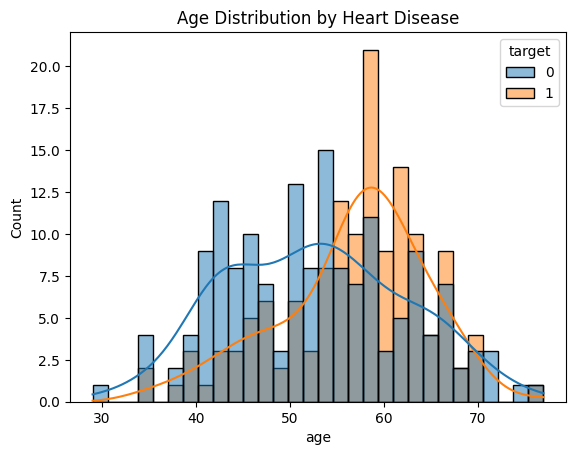

In [12]:
#Analysing Features
sns.histplot(data=df, x='age', hue='target', bins=30, kde=True)
plt.title("Age Distribution by Heart Disease")
plt.show()

Patients with heart disease tend to cluster in certain age ranges, suggesting age may be a contributing factor.

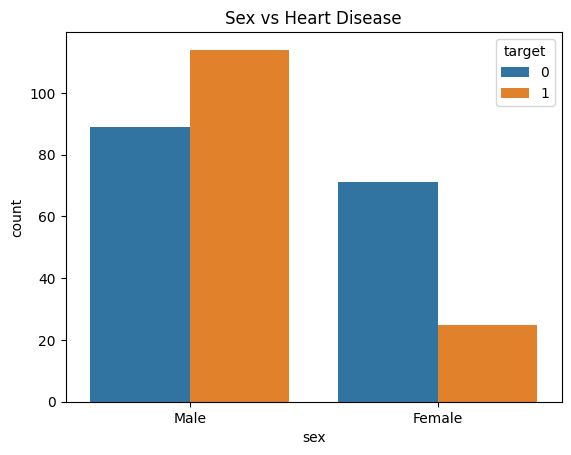

In [13]:
sns.countplot(x='sex', hue='target', data=df)
plt.title("Sex vs Heart Disease")
plt.show()

One gender may show a higher proportion of heart disease cases,indicating gender may influence the risk.

Part 3: Data Preprocessing

In [14]:
#One-hot encoding categorical columns
categorical_cols = ['cp', 'thal', 'slope', 'restecg', 'ca']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,...,cp_typical angina,thal_normal,thal_reversable defect,slope_flat,slope_upsloping,restecg_normal,restecg_st-t abnormality,ca_1.0,ca_2.0,ca_3.0
0,1,63,Male,Cleveland,145.0,233.0,True,150.0,False,2.3,...,True,False,False,False,False,False,False,False,False,False
1,2,67,Male,Cleveland,160.0,286.0,False,108.0,True,1.5,...,False,True,False,True,False,False,False,False,False,True
2,3,67,Male,Cleveland,120.0,229.0,False,129.0,True,2.6,...,False,False,True,True,False,False,False,False,True,False
3,4,37,Male,Cleveland,130.0,250.0,False,187.0,False,3.5,...,False,True,False,False,False,True,False,False,False,False
4,5,41,Female,Cleveland,130.0,204.0,False,172.0,False,1.4,...,False,True,False,False,True,False,False,False,False,False


In [16]:
df = df.drop(['id', 'dataset'], axis=1)

In [17]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop('num', axis=1)

In [18]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
X = df.drop('target', axis=1)
y = df['target']

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Part 4: Model Building

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients['Absolute'] = coefficients['Coefficient'].abs()
coefficients.sort_values(by='Absolute', ascending=False).head(10)

,Feature,Coefficient,Absolute
5,ca,1.066864,1.066864
8,cp_non-anginal,-0.794789,0.794789
6,sex_Male,0.693375,0.693375
9,cp_typical angina,-0.501362,0.501362
13,exang_True,0.445074,0.445074
4,oldpeak,0.430082,0.430082
17,thal_reversable defect,0.402600,0.402600
1,trestbps,0.372868,0.372868
14,slope_flat,0.346499,0.346499
3,thalch,-0.323569,0.323569


The feature with the highest absolute coefficient has the strongest influence on the predictions.

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

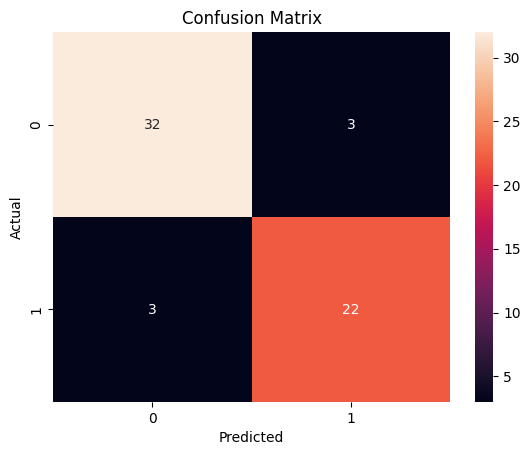

Confusion Matrix:
 [[32  3]
 [ 3 22]]


In [25]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix:\n", cm)

False Positives and False Negatives can be identified from the matrix.

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        35
           1       0.88      0.88      0.88        25

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



In medical diagnosis,Recall is critical because it was measures how many actual heart disease patients were correctly identified.Missing a patient(False Negative) can be life-threatening, so detecting as many as real cases as possible is more important than avoiding false alarms.

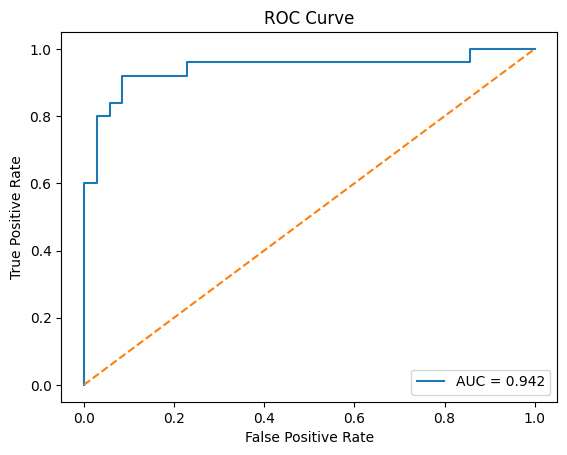

AUC Score: 0.9417142857142857


In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

AUC close to 1 indicates a strong model, while 0.5 indicates random guessing.

Logistic Regression performed reasonably well for predicting heart disease.Features like chest pain type,maximum heart rate,and ST depression showed strong influence on predictions.Evaluation metrics such as the Recall and ROC-AUC help assess the model’s effectiveness in a medical context.